# F1 Cornering Classification

This notebook contains only the active modelling pipeline:

1. Load the existing manifests and fixed session split.
2. Train or load the CNN.
3. Train the delta-only logistic regression.
4. Generate lap-level CNN probabilities.
5. Compare CNN aggregation methods.
6. Fuse CNN and delta probabilities on the validation set.

The test set remains untouched during model development.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 1. Configuration


In [19]:
batch_size = 16
num_epochs = 15
learning_rate = 0.0001
seed = 42

# Set to True only when you deliberately want to retrain and overwrite
# the saved best_resnet18.pth checkpoint.
TRAIN_CNN = True #False

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


## 2. Project paths and saved manifests


In [20]:
possible_project_roots = [
    Path.cwd(),
    Path.cwd().parent,
]

project_root = next(
    (
        path.resolve()
        for path in possible_project_roots
        if (
            path
            / "Data"
            / "manifests"
            / "image-manifest-with-split.csv"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root containing "
        "Data/manifests/image-manifest-with-split.csv.\n"
        f"Current working directory: {Path.cwd()}"
    )

data_root = project_root / "Data"
manifest_dir = data_root / "manifests"

image_manifest_path = manifest_dir / "image-manifest.csv"
lap_manifest_path = manifest_dir / "lap-manifest.csv"

split_image_manifest_path = (
    manifest_dir / "image-manifest-with-split.csv"
)

split_lap_manifest_path = (
    manifest_dir / "lap-manifest-with-split.csv"
)

code_directory = project_root / "Code"
best_model_path = (
    code_directory / "best_resnet18.pth"
    if code_directory.exists()
    else Path.cwd() / "best_resnet18.pth"
)

print("Project root:", project_root)
print("Manifest directory:", manifest_dir)
print("CNN checkpoint:", best_model_path)


Project root: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project
Manifest directory: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests
CNN checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18.pth


In [21]:
image_manifest = pd.read_csv(image_manifest_path)
lap_manifest = pd.read_csv(lap_manifest_path)

image_manifest_with_split = pd.read_csv(
    split_image_manifest_path
)

lap_manifest_with_split = pd.read_csv(
    split_lap_manifest_path
)

valid_splits = {"train", "validation", "test"}

assert len(image_manifest) == 788
assert len(lap_manifest) == 197
assert len(image_manifest_with_split) == 788
assert len(lap_manifest_with_split) == 197

assert set(
    image_manifest_with_split["split"].unique()
) == valid_splits

assert set(
    lap_manifest_with_split["split"].unique()
) == valid_splits

assert lap_manifest_with_split[
    "global_lap_num"
].is_unique

assert (
    image_manifest_with_split
    .groupby("global_lap_num")
    .size()
    .eq(4)
    .all()
)

print("Saved manifests loaded and validated.")


Saved manifests loaded and validated.


## 3. Fixed train, validation and test subsets


In [22]:
train_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

train_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(train_image_df) == 556
assert len(validation_image_df) == 108
assert len(test_image_df) == 124

assert len(train_lap_df) == 139
assert len(validation_lap_df) == 27
assert len(test_lap_df) == 31

print("Training images:", len(train_image_df))
print("Validation images:", len(validation_image_df))
print("Reserved test images:", len(test_image_df))


Training images: 556
Validation images: 108
Reserved test images: 124


## 4. Image transforms, datasets and data loaders


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])


class ManifestImageDataset(Dataset):
    def __init__(
        self,
        manifest_df,
        project_root,
        transform=None,
    ):
        self.manifest_df = (
            manifest_df.copy().reset_index(drop=True)
        )
        self.project_root = Path(project_root).resolve()
        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, index):
        row = self.manifest_df.iloc[index]

        image_path = Path(
            row["cnn_repo_relative_path"]
        )

        if not image_path.is_absolute():
            image_path = self.project_root / image_path

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image was not found:\n{image_path}"
            )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        label = int(row["class_index"])

        return image, label


Using device: cuda


In [24]:
train_dataset = ManifestImageDataset(
    train_image_df,
    project_root,
    train_transform,
)

validation_dataset = ManifestImageDataset(
    validation_image_df,
    project_root,
    eval_transform,
)

test_dataset = ManifestImageDataset(
    test_image_df,
    project_root,
    eval_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Reserved test batches:", len(test_loader))


Train batches: 35
Validation batches: 7
Reserved test batches: 8


## 5. CNN definition and training

### 5.1 Frozen CNN configuration and model

In [72]:
class_names = [
    "optimal_laps",
    "standard_laps",
    "sub_standard_laps",
]

num_classes = len(class_names)

model = models.resnet18(weights=weights)

# model.fc = nn.Linear(
#     model.fc.in_features,
#     num_classes,
# )

# model = model.to(device)

# criterion = nn.CrossEntropyLoss()

# optimizer = optim.Adam(
#     model.parameters(),
#     lr=learning_rate,
# )

partial_num_epochs = 30

# Smaller learning rate for the pretrained layer.
layer4_learning_rate = 1e-5

# Larger learning rate for the newly created classifier.
classifier_learning_rate = 5e-4

weight_decay = 1e-4

early_stopping_patience = 5
early_stopping_min_delta = 1e-4

TRAIN_PARTIAL_CNN = True

partial_checkpoint_path = (
    project_root
    / "Code"
    / "best_resnet18_partial_throttle.pth"
)


# Start from the original ImageNet-pretrained model,
# not one of the previously trained checkpoints.
model = models.resnet18(
    weights=weights
)

# Freeze the entire network first.
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the classifier.
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes,
)

# Unfreeze the final ResNet block.
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# The new classifier is trainable by default.
for parameter in model.fc.parameters():
    parameter.requires_grad = True

model = model.to(device)


trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Trainable parameters:",
    trainable_parameter_count,
)

print(
    "Total parameters:",
    total_parameter_count,
)

print(
    "Trainable percentage:",
    f"{100 * trainable_parameter_count / total_parameter_count:.4f}%",
)

Trainable parameters: 8395267
Total parameters: 11178051
Trainable percentage: 75.1049%


The test loader is intentionally not evaluated here. The fixed test set remains reserved until the CNN, delta model and fusion method have been selected.


### 5.2 Calculate class weights

In [73]:
training_class_counts = (
    train_lap_df["class_index"]
    .value_counts()
    .reindex(
        range(num_classes),
        fill_value=0,
    )
)

if training_class_counts.eq(0).any():
    raise ValueError(
        "At least one class has no training examples."
    )


# Full inverse-frequency weighting was too aggressive.
# Taking the square root gives gentler class balancing.
inverse_frequency_weights = (
    len(train_lap_df)
    / (
        num_classes
        * training_class_counts.to_numpy()
    )
)

sqrt_class_weights_numpy = np.sqrt(
    inverse_frequency_weights
)

# Normalise so the average weight is 1.
sqrt_class_weights_numpy = (
    sqrt_class_weights_numpy
    / sqrt_class_weights_numpy.mean()
)

class_weights = torch.tensor(
    sqrt_class_weights_numpy,
    dtype=torch.float32,
    device=device,
)

class_weight_summary = pd.DataFrame({
    "class_name": class_names,
    "lap_count":
        training_class_counts.to_numpy(),
    "loss_weight":
        sqrt_class_weights_numpy,
})

display(class_weight_summary)

,class_name,lap_count,loss_weight
0,optimal_laps,35,1.106108
1,standard_laps,69,0.787784
2,sub_standard_laps,35,1.106108


In [74]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
)

optimizer = optim.Adam(
    [
        {
            "params":
                model.layer4.parameters(),

            "lr":
                layer4_learning_rate,
        },
        {
            "params":
                model.fc.parameters(),

            "lr":
                classifier_learning_rate,
        },
    ],
    weight_decay=weight_decay,
)

### 5.3 Train one frozen-backbone epoch

In [75]:
def train_partial_epoch(
    model,
    loader,
    criterion,
    optimizer,
):
    # Keep all frozen layers in evaluation mode.
    model.eval()

    # Only the unfrozen final block and classifier
    # should behave as training layers.
    model.layer4.train()
    model.fc.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(
            logits,
            labels,
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item()
            * inputs.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )

### 5.4 Calculate image-level validation loss

In [57]:
def evaluate_image_epoch(
    model,
    loader,
    criterion,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            running_loss += (
                loss.item()
                * inputs.size(0)
            )

            predictions = logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )

### 5.5 Collect image probabilities in manifest order

In [58]:
def collect_image_probabilities(
    model,
    loader,
    manifest_df,
):
    model.eval()

    probability_batches = []
    prediction_batches = []
    label_batches = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = logits.argmax(
                dim=1
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

            prediction_batches.append(
                predictions.cpu().numpy()
            )

            label_batches.append(
                labels.cpu().numpy()
            )

    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    predictions = np.concatenate(
        prediction_batches,
        axis=0,
    )

    labels = np.concatenate(
        label_batches,
        axis=0,
    )

    if len(manifest_df) != len(labels):
        raise ValueError(
            "Manifest and loader output lengths differ."
        )

    if not np.array_equal(
        manifest_df[
            "class_index"
        ].to_numpy(),
        labels,
    ):
        raise ValueError(
            "Manifest rows and loader labels are "
            "not aligned."
        )

    results = (
        manifest_df.copy()
        .reset_index(drop=True)
    )

    results[
        "probability_optimal"
    ] = probabilities[:, 0]

    results[
        "probability_standard"
    ] = probabilities[:, 1]

    results[
        "probability_sub_standard"
    ] = probabilities[:, 2]

    results[
        "image_predicted_class_index"
    ] = predictions

    return results

### 5.6 Aggregate only the two throttle images per lap

In [59]:
def aggregate_throttle_probabilities(
    image_results,
):
    throttle_images = (
        image_results[
            image_results["signal_type"]
            == "throttle"
        ]
        .copy()
        .reset_index(drop=True)
    )

    throttle_counts = (
        throttle_images
        .groupby("global_lap_num")
        .size()
    )

    if not throttle_counts.eq(2).all():
        problematic_laps = (
            throttle_counts[
                ~throttle_counts.eq(2)
            ]
        )

        raise ValueError(
            "At least one validation lap does not "
            "have exactly two throttle images:\n"
            f"{problematic_laps}"
        )

    probability_columns = [
        "probability_optimal",
        "probability_standard",
        "probability_sub_standard",
    ]

    throttle_probabilities = (
        throttle_images
        .groupby(
            "global_lap_num",
            as_index=False,
        )[probability_columns]
        .mean()
        .rename(columns={
            "probability_optimal":
                "throttle_probability_optimal",

            "probability_standard":
                "throttle_probability_standard",

            "probability_sub_standard":
                "throttle_probability_sub_standard",
        })
    )

    lap_metadata = (
        throttle_images
        .groupby(
            "global_lap_num",
            as_index=False,
        )
        .agg(
            session=("session", "first"),
            session_lap_num=(
                "session_lap_num",
                "first",
            ),
            class_name=(
                "class_name",
                "first",
            ),
            class_index=(
                "class_index",
                "first",
            ),
        )
    )

    throttle_lap_results = (
        lap_metadata
        .merge(
            throttle_probabilities,
            on="global_lap_num",
            how="inner",
            validate="one_to_one",
        )
        .sort_values(
            "global_lap_num"
        )
        .reset_index(drop=True)
    )

    throttle_probability_matrix = (
        throttle_lap_results[[
            "throttle_probability_optimal",
            "throttle_probability_standard",
            "throttle_probability_sub_standard",
        ]]
        .to_numpy()
    )

    throttle_lap_results[
        "throttle_predicted_class_index"
    ] = throttle_probability_matrix.argmax(
        axis=1
    )

    return throttle_lap_results

### 5.7 Frozen CNN training loop

In [76]:
partial_training_history = []

if TRAIN_PARTIAL_CNN:
    best_throttle_balanced_accuracy = -np.inf
    best_throttle_accuracy = -np.inf
    best_epoch = None

    epochs_without_improvement = 0

    for epoch in range(
        partial_num_epochs
    ):
        train_loss, train_accuracy = (
            train_partial_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
            )
        )

        (
            validation_loss,
            validation_image_accuracy,
        ) = evaluate_image_epoch(
            model,
            val_loader,
            criterion,
        )

        validation_image_results = (
            collect_image_probabilities(
                model,
                val_loader,
                validation_image_df,
            )
        )

        validation_throttle_results = (
            aggregate_throttle_probabilities(
                validation_image_results
            )
        )

        validation_true_labels = (
            validation_throttle_results[
                "class_index"
            ].to_numpy()
        )

        validation_throttle_predictions = (
            validation_throttle_results[
                "throttle_predicted_class_index"
            ].to_numpy()
        )

        throttle_accuracy = accuracy_score(
            validation_true_labels,
            validation_throttle_predictions,
        )

        throttle_balanced_accuracy = (
            balanced_accuracy_score(
                validation_true_labels,
                validation_throttle_predictions,
            )
        )

        partial_training_history.append({
            "epoch":
                epoch + 1,

            "train_loss":
                train_loss,

            "train_image_accuracy":
                train_accuracy,

            "validation_loss":
                validation_loss,

            "validation_image_accuracy":
                validation_image_accuracy,

            "validation_throttle_accuracy":
                throttle_accuracy,

            "validation_throttle_balanced_accuracy":
                throttle_balanced_accuracy,
        })

        print(
            f"Epoch {epoch + 1:02d}/"
            f"{partial_num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Image Acc: {train_accuracy:.4f} | "
            f"Val Loss: {validation_loss:.4f} | "
            f"Val Image Acc: "
            f"{validation_image_accuracy:.4f} | "
            f"Throttle Lap Acc: "
            f"{throttle_accuracy:.4f} | "
            f"Throttle Balanced Acc: "
            f"{throttle_balanced_accuracy:.4f}"
        )

        balanced_improved = (
            throttle_balanced_accuracy
            >
            best_throttle_balanced_accuracy
            + early_stopping_min_delta
        )

        tied_but_accuracy_improved = (
            np.isclose(
                throttle_balanced_accuracy,
                best_throttle_balanced_accuracy,
                atol=early_stopping_min_delta,
            )
            and (
                throttle_accuracy
                > best_throttle_accuracy
            )
        )

        if (
            balanced_improved
            or tied_but_accuracy_improved
        ):
            best_throttle_balanced_accuracy = (
                throttle_balanced_accuracy
            )

            best_throttle_accuracy = (
                throttle_accuracy
            )

            best_epoch = epoch + 1
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                partial_checkpoint_path,
            )

            print(
                "  Saved new best checkpoint."
            )

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                "Early stopping triggered after "
                f"{epoch + 1} epochs."
            )
            break


    print(
        "\nBest epoch:",
        best_epoch,
    )

    print(
        "Best throttle validation accuracy:",
        f"{best_throttle_accuracy:.4f}",
    )

    print(
        "Best throttle validation "
        "balanced accuracy:",
        f"{best_throttle_balanced_accuracy:.4f}",
    )

    partial_training_history_df = (
        pd.DataFrame(
            partial_training_history
        )
    )

    display(
        partial_training_history_df
    )

Epoch 01/30 | Train Loss: 1.1055 | Train Image Acc: 0.4263 | Val Loss: 1.1680 | Val Image Acc: 0.3519 | Throttle Lap Acc: 0.4444 | Throttle Balanced Acc: 0.3956
  Saved new best checkpoint.
Epoch 02/30 | Train Loss: 0.9841 | Train Image Acc: 0.5396 | Val Loss: 1.1105 | Val Image Acc: 0.5093 | Throttle Lap Acc: 0.5556 | Throttle Balanced Acc: 0.4725
  Saved new best checkpoint.
Epoch 03/30 | Train Loss: 0.9108 | Train Image Acc: 0.5827 | Val Loss: 1.1254 | Val Image Acc: 0.4444 | Throttle Lap Acc: 0.5926 | Throttle Balanced Acc: 0.5201
  Saved new best checkpoint.
Epoch 04/30 | Train Loss: 0.8266 | Train Image Acc: 0.6888 | Val Loss: 1.1179 | Val Image Acc: 0.4630 | Throttle Lap Acc: 0.5556 | Throttle Balanced Acc: 0.4725
Epoch 05/30 | Train Loss: 0.7759 | Train Image Acc: 0.7158 | Val Loss: 1.1104 | Val Image Acc: 0.3889 | Throttle Lap Acc: 0.5185 | Throttle Balanced Acc: 0.5128
Epoch 06/30 | Train Loss: 0.7225 | Train Image Acc: 0.7446 | Val Loss: 1.1418 | Val Image Acc: 0.3519 | Thro

,epoch,train_loss,train_image_accuracy,validation_loss,validation_image_accuracy,validation_throttle_accuracy,validation_throttle_balanced_accuracy
0,1,1.105546,0.426259,1.167974,0.351852,0.444444,0.395604
1,2,0.984146,0.539568,1.110466,0.509259,0.555556,0.472527
2,3,0.910833,0.582734,1.125384,0.444444,0.592593,0.520147
3,4,0.826621,0.688849,1.117850,0.462963,0.555556,0.472527
4,5,0.775944,0.715827,1.110433,0.388889,0.518519,0.512821
5,6,0.722479,0.744604,1.141792,0.351852,0.407407,0.435897
6,7,0.645132,0.784173,1.152430,0.361111,0.481481,0.531136
7,8,0.583722,0.814748,1.191249,0.416667,0.592593,0.520147
8,9,0.486850,0.893885,1.183988,0.388889,0.481481,0.465201
9,10,0.428226,0.895683,1.210851,0.379630,0.518519,0.512821


### 5.8 Load the best frozen checkpoint

In [77]:
if not partial_checkpoint_path.exists():
    raise FileNotFoundError(
        "Partial CNN checkpoint was not found:\n"
        f"{partial_checkpoint_path}"
    )

model.load_state_dict(
    torch.load(
        partial_checkpoint_path,
        map_location=device,
        weights_only=True,
    )
)

model = model.to(device)
model.eval()

print(
    "Loaded partial CNN checkpoint:",
    partial_checkpoint_path,
)

Loaded partial CNN checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_partial_throttle.pth


### 5.9 Generate the final validation throttle probabilities

In [78]:
best_validation_image_results = (
    collect_image_probabilities(
        model,
        val_loader,
        validation_image_df,
    )
)

best_throttle_validation_results = (
    aggregate_throttle_probabilities(
        best_validation_image_results
    )
)

y_throttle_validation = (
    best_throttle_validation_results[
        "class_index"
    ].to_numpy()
)

throttle_validation_predictions = (
    best_throttle_validation_results[
        "throttle_predicted_class_index"
    ].to_numpy()
)

partial_throttle_accuracy = accuracy_score(
    y_throttle_validation,
    throttle_validation_predictions,
)

partial_throttle_balanced_accuracy = (
    balanced_accuracy_score(
        y_throttle_validation,
        throttle_validation_predictions,
    )
)

print(
    "Partial CNN throttle validation accuracy:",
    f"{partial_throttle_accuracy:.4f}",
)

print(
    "Partial CNN throttle validation "
    "balanced accuracy:",
    f"{partial_throttle_balanced_accuracy:.4f}",
)

Partial CNN throttle validation accuracy: 0.5556
Partial CNN throttle validation balanced accuracy: 0.5385


Classification report:

In [79]:
print(
    classification_report(
        y_throttle_validation,
        throttle_validation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

                   precision    recall  f1-score   support

     optimal_laps     0.4286    0.4286    0.4286         7
    standard_laps     0.5714    0.6154    0.5926        13
sub_standard_laps     0.6667    0.5714    0.6154         7

         accuracy                         0.5556        27
        macro avg     0.5556    0.5385    0.5455        27
     weighted avg     0.5591    0.5556    0.5560        27



Confusion matrix:

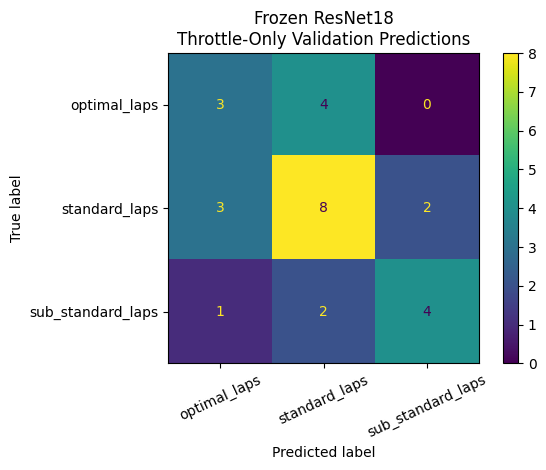

In [80]:
ConfusionMatrixDisplay.from_predictions(
    y_throttle_validation,
    throttle_validation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Frozen ResNet18\n"
    "Throttle-Only Validation Predictions"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Save the probabilities:

In [81]:
throttle_validation_probability_df = (
    best_throttle_validation_results[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
        "throttle_predicted_class_index",
        "throttle_probability_optimal",
        "throttle_probability_standard",
        "throttle_probability_sub_standard",
    ]]
    .copy()
)

partial_throttle_probability_path = (
    manifest_dir
    / "partial-cnn-throttle-validation-probabilities.csv"
)

throttle_validation_probability_df.to_csv(
    partial_throttle_probability_path,
    index=False,
)

print(
    "Saved partial CNN probabilities:",
    partial_throttle_probability_path,
)

Saved partial CNN probabilities: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\partial-cnn-throttle-validation-probabilities.csv


## 6. Delta-only logistic regression


In [28]:
delta_feature_columns = [
    "delta_1_seconds",
    "delta_2_seconds",
]

delta_available_mask = (
    lap_manifest_with_split[
        "delta_1_seconds"
    ].notna()
    & lap_manifest_with_split[
        "delta_2_seconds"
    ].notna()
)

delta_laps = (
    lap_manifest_with_split[
        delta_available_mask
    ]
    .copy()
    .reset_index(drop=True)
)

delta_train_df = (
    delta_laps[
        delta_laps["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_validation_df = (
    delta_laps[
        delta_laps["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_test_df = (
    delta_laps[
        delta_laps["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

X_delta_train = delta_train_df[
    delta_feature_columns
].to_numpy()

y_delta_train = delta_train_df[
    "class_index"
].to_numpy()

X_delta_validation = delta_validation_df[
    delta_feature_columns
].to_numpy()

y_delta_validation = delta_validation_df[
    "class_index"
].to_numpy()

print("Delta training laps:", len(delta_train_df))
print(
    "Delta validation laps:",
    len(delta_validation_df),
)
print(
    "Delta test laps reserved:",
    len(delta_test_df),
)


Delta training laps: 111
Delta validation laps: 27
Delta test laps reserved: 31


In [29]:
training_class_counts = (
    delta_train_df["class_index"]
    .value_counts()
)

majority_class_index = int(
    training_class_counts.idxmax()
)

majority_validation_predictions = np.full(
    len(y_delta_validation),
    majority_class_index,
)

majority_validation_accuracy = accuracy_score(
    y_delta_validation,
    majority_validation_predictions,
)

majority_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        majority_validation_predictions,
    )
)

delta_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    ),
])

delta_model.fit(
    X_delta_train,
    y_delta_train,
)

delta_validation_predictions = (
    delta_model.predict(
        X_delta_validation
    )
)

delta_validation_probabilities = (
    delta_model.predict_proba(
        X_delta_validation
    )
)

delta_validation_accuracy = accuracy_score(
    y_delta_validation,
    delta_validation_predictions,
)

delta_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        delta_validation_predictions,
    )
)

print(
    "Majority baseline accuracy:",
    f"{majority_validation_accuracy:.4f}",
)

print(
    "Majority baseline balanced accuracy:",
    f"{majority_validation_balanced_accuracy:.4f}",
)

print(
    "Delta validation accuracy:",
    f"{delta_validation_accuracy:.4f}",
)

print(
    "Delta validation balanced accuracy:",
    f"{delta_validation_balanced_accuracy:.4f}",
)


Majority baseline accuracy: 0.4815
Majority baseline balanced accuracy: 0.3333
Delta validation accuracy: 0.5926
Delta validation balanced accuracy: 0.6300


                   precision    recall  f1-score   support

     optimal_laps     0.3846    0.7143    0.5000         7
    standard_laps     0.6667    0.4615    0.5455        13
sub_standard_laps     1.0000    0.7143    0.8333         7

         accuracy                         0.5926        27
        macro avg     0.6838    0.6300    0.6263        27
     weighted avg     0.6800    0.5926    0.6083        27



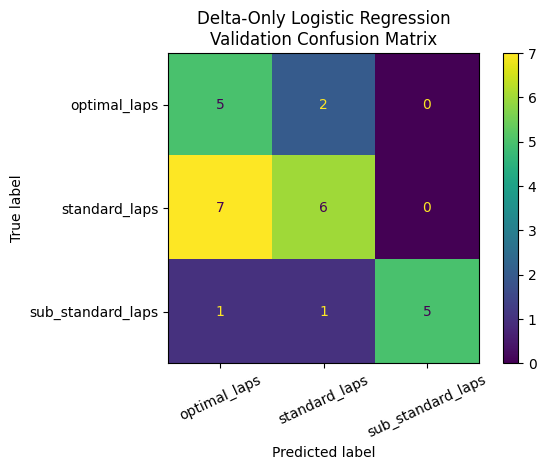

In [30]:
print(
    classification_report(
        y_delta_validation,
        delta_validation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_delta_validation,
    delta_validation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Delta-Only Logistic Regression\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [31]:
delta_model_class_order = (
    delta_model.named_steps[
        "classifier"
    ].classes_
)

assert np.array_equal(
    delta_model_class_order,
    np.arange(num_classes),
)

delta_validation_probability_df = pd.DataFrame({
    "global_lap_num":
        delta_validation_df[
            "global_lap_num"
        ].to_numpy(),

    "true_class_index":
        y_delta_validation,

    "delta_predicted_class_index":
        delta_validation_predictions,

    "delta_probability_optimal":
        delta_validation_probabilities[:, 0],

    "delta_probability_standard":
        delta_validation_probabilities[:, 1],

    "delta_probability_sub_standard":
        delta_validation_probabilities[:, 2],
})

delta_validation_probability_path = (
    manifest_dir
    / "delta-validation-probabilities.csv"
)

delta_validation_probability_df.to_csv(
    delta_validation_probability_path,
    index=False,
)

display(
    delta_validation_probability_df.head()
)

print(
    "Saved delta validation probabilities:",
    delta_validation_probability_path,
)


,global_lap_num,true_class_index,delta_predicted_class_index,delta_probability_optimal,delta_probability_standard,delta_probability_sub_standard
0,99,1,0,0.556025,0.401710,0.042265
1,100,2,2,0.021701,0.147629,0.830670
2,102,1,1,0.179959,0.455430,0.364611
3,104,2,0,0.536363,0.419208,0.044428
4,163,1,0,0.558351,0.412102,0.029547


Saved delta validation probabilities: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\delta-validation-probabilities.csv


## 7. CNN validation outputs and lap-level aggregation


In [82]:
validation_logits_batches = []
validation_probability_batches = []
validation_prediction_batches = []
validation_label_batches = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = logits.argmax(dim=1)

        validation_logits_batches.append(
            logits.cpu().numpy()
        )

        validation_probability_batches.append(
            probabilities.cpu().numpy()
        )

        validation_prediction_batches.append(
            predictions.cpu().numpy()
        )

        validation_label_batches.append(
            labels.numpy()
        )

validation_image_logits = np.concatenate(
    validation_logits_batches,
    axis=0,
)

validation_image_probabilities = np.concatenate(
    validation_probability_batches,
    axis=0,
)

validation_image_predictions = np.concatenate(
    validation_prediction_batches,
    axis=0,
)

validation_image_labels = np.concatenate(
    validation_label_batches,
    axis=0,
)

assert validation_image_logits.shape == (108, 3)

assert np.array_equal(
    validation_image_df[
        "class_index"
    ].to_numpy(),
    validation_image_labels,
)

print(
    "Validation logits shape:",
    validation_image_logits.shape,
)

print(
    "Validation probabilities shape:",
    validation_image_probabilities.shape,
)


Validation logits shape: (108, 3)
Validation probabilities shape: (108, 3)


In [33]:
cnn_aggregation_image_df = (
    validation_image_df.copy()
)

for class_index, class_label in enumerate([
    "optimal",
    "standard",
    "sub_standard",
]):
    cnn_aggregation_image_df[
        f"logit_{class_label}"
    ] = validation_image_logits[
        :,
        class_index,
    ]

    cnn_aggregation_image_df[
        f"probability_{class_label}"
    ] = validation_image_probabilities[
        :,
        class_index,
    ]

cnn_aggregation_image_df[
    "image_predicted_class_index"
] = validation_image_predictions

cnn_aggregation_image_df[
    "image_predicted_class_name"
] = [
    class_names[class_index]
    for class_index
    in validation_image_predictions
]

display(
    cnn_aggregation_image_df[[
        "global_lap_num",
        "signal_type",
        "hit_number",
        "class_name",
        "image_predicted_class_name",
        "probability_optimal",
        "probability_standard",
        "probability_sub_standard",
    ]].head(12)
)


,global_lap_num,signal_type,hit_number,class_name,image_predicted_class_name,probability_optimal,probability_standard,probability_sub_standard
0,99,brake,1,standard_laps,optimal_laps,0.721920,0.014120,0.263960
1,99,brake,2,standard_laps,standard_laps,0.348004,0.554309,0.097686
2,99,throttle,1,standard_laps,standard_laps,0.456348,0.530465,0.013188
3,99,throttle,2,standard_laps,sub_standard_laps,0.008896,0.192917,0.798186
4,100,brake,1,sub_standard_laps,sub_standard_laps,0.394816,0.109289,0.495895
5,100,brake,2,sub_standard_laps,standard_laps,0.001330,0.993419,0.005251
6,100,throttle,1,sub_standard_laps,sub_standard_laps,0.045638,0.087146,0.867216
7,100,throttle,2,sub_standard_laps,standard_laps,0.001918,0.985090,0.012992
8,102,brake,1,standard_laps,standard_laps,0.096003,0.895195,0.008802
9,102,brake,2,standard_laps,standard_laps,0.000318,0.992991,0.006692


In [34]:
probability_columns = [
    "probability_optimal",
    "probability_standard",
    "probability_sub_standard",
]

logit_columns = [
    "logit_optimal",
    "logit_standard",
    "logit_sub_standard",
]


def numpy_softmax(values):
    shifted_values = (
        values
        - values.max(
            axis=1,
            keepdims=True,
        )
    )

    exponentials = np.exp(
        shifted_values
    )

    return (
        exponentials
        / exponentials.sum(
            axis=1,
            keepdims=True,
        )
    )


def majority_vote_with_probability_tiebreak(
    image_predictions,
    image_probabilities,
):
    vote_counts = np.bincount(
        image_predictions,
        minlength=num_classes,
    )

    tied_classes = np.flatnonzero(
        vote_counts == vote_counts.max()
    )

    if len(tied_classes) == 1:
        return int(tied_classes[0])

    mean_probabilities = (
        image_probabilities.mean(axis=0)
    )

    return int(
        tied_classes[
            mean_probabilities[
                tied_classes
            ].argmax()
        ]
    )


In [36]:
aggregation_records = []

for global_lap_num, lap_images in (
    cnn_aggregation_image_df
    .groupby("global_lap_num")
):
    lap_images = (
        lap_images
        .sort_values([
            "signal_type",
            "hit_number",
        ])
        .reset_index(drop=True)
    )

    if len(lap_images) != 4:
        raise ValueError(
            f"Lap {global_lap_num} has "
            f"{len(lap_images)} images."
        )

    first_row = lap_images.iloc[0]

    all_probabilities = (
        lap_images[
            probability_columns
        ].to_numpy()
    )

    all_logits = (
        lap_images[
            logit_columns
        ].to_numpy()
    )

    all_image_predictions = (
        lap_images[
            "image_predicted_class_index"
        ].to_numpy()
    )

    brake_images = lap_images[
        lap_images["signal_type"]
        == "brake"
    ]

    throttle_images = lap_images[
        lap_images["signal_type"]
        == "throttle"
    ]

    mean_softmax_probabilities = (
        all_probabilities.mean(axis=0)
    )

    mean_logit_probabilities = (
        numpy_softmax(
            all_logits.mean(
                axis=0,
                keepdims=True,
            )
        )[0]
    )

    brake_probabilities = (
        brake_images[
            probability_columns
        ].to_numpy().mean(axis=0)
    )

    throttle_probabilities = (
        throttle_images[
            probability_columns
        ].to_numpy().mean(axis=0)
    )

    aggregation_records.append({
        "global_lap_num":
            int(global_lap_num),

        "session":
            int(first_row["session"]),

        "session_lap_num":
            int(first_row["session_lap_num"]),

        "class_name":
            first_row["class_name"],

        "class_index":
            int(first_row["class_index"]),

        "mean_softmax_prediction":
            int(mean_softmax_probabilities.argmax()),

        "mean_logits_prediction":
            int(mean_logit_probabilities.argmax()),

        "majority_vote_prediction":
            majority_vote_with_probability_tiebreak(
                all_image_predictions,
                all_probabilities,
            ),

        "brake_only_prediction":
            int(brake_probabilities.argmax()),

        "throttle_only_prediction":
            int(throttle_probabilities.argmax()),

        "mean_softmax_probability_optimal":
            mean_softmax_probabilities[0],

        "mean_softmax_probability_standard":
            mean_softmax_probabilities[1],

        "mean_softmax_probability_sub_standard":
            mean_softmax_probabilities[2],

        "mean_logits_probability_optimal":
            mean_logit_probabilities[0],

        "mean_logits_probability_standard":
            mean_logit_probabilities[1],

        "mean_logits_probability_sub_standard":
            mean_logit_probabilities[2],

        "brake_probability_optimal":
            brake_probabilities[0],

        "brake_probability_standard":
            brake_probabilities[1],

        "brake_probability_sub_standard":
            brake_probabilities[2],

        "throttle_probability_optimal":
            throttle_probabilities[0],

        "throttle_probability_standard":
            throttle_probabilities[1],

        "throttle_probability_sub_standard":
            throttle_probabilities[2],
    })

cnn_aggregation_results = (
    pd.DataFrame(aggregation_records)
    .sort_values("global_lap_num")
    .reset_index(drop=True)
)

# assert len(cnn_aggregation_results) == 18

display(
    cnn_aggregation_results.head()
)


,global_lap_num,session,session_lap_num,class_name,class_index,mean_softmax_prediction,mean_logits_prediction,majority_vote_prediction,brake_only_prediction,throttle_only_prediction,...,mean_softmax_probability_sub_standard,mean_logits_probability_optimal,mean_logits_probability_standard,mean_logits_probability_sub_standard,brake_probability_optimal,brake_probability_standard,brake_probability_sub_standard,throttle_probability_optimal,throttle_probability_standard,throttle_probability_sub_standard
0,99,11,1,standard_laps,1,0,0,1,0,2,...,0.293255,0.375996,0.353951,0.270052,0.534962,0.284215,0.180823,0.232622,0.361691,0.405687
1,100,11,2,sub_standard_laps,2,1,1,1,1,1,...,0.345339,0.036699,0.778824,0.184478,0.198073,0.551354,0.250573,0.023778,0.536118,0.440104
2,102,11,4,standard_laps,1,1,1,1,1,1,...,0.145942,0.019768,0.927518,0.052714,0.048160,0.944093,0.007747,0.050829,0.665034,0.284137
3,104,11,6,sub_standard_laps,2,1,1,1,1,2,...,0.248625,0.088240,0.701637,0.210123,0.072424,0.816569,0.111007,0.328714,0.285044,0.386243
4,163,18,2,standard_laps,1,0,0,0,0,0,...,0.141570,0.435506,0.398901,0.165593,0.404858,0.333109,0.262033,0.502803,0.476089,0.021108


In [38]:
y_cnn_validation = (
    cnn_aggregation_results[
        "class_index"
    ].to_numpy()
)

aggregation_methods = {
    "Mean softmax — all four images":
        "mean_softmax_prediction",

    "Mean logits, then softmax":
        "mean_logits_prediction",

    "Majority vote":
        "majority_vote_prediction",

    "Brake images only":
        "brake_only_prediction",

    "Throttle images only":
        "throttle_only_prediction",
}

aggregation_metric_records = []

for method_name, prediction_column in (
    aggregation_methods.items()
):
    predictions = (
        cnn_aggregation_results[
            prediction_column
        ].to_numpy()
    )

    aggregation_metric_records.append({
        "aggregation_method":
            method_name,

        "accuracy":
            accuracy_score(
                y_cnn_validation,
                predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_cnn_validation,
                predictions,
            ),

        "correct_laps":
            int(
                (
                    y_cnn_validation
                    == predictions
                ).sum()
            ),

        "total_laps":
            len(y_cnn_validation),
    })

cnn_aggregation_comparison = (
    pd.DataFrame(
        aggregation_metric_records
    )
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    cnn_aggregation_comparison
)


,aggregation_method,accuracy,balanced_accuracy,correct_laps,total_laps
0,Throttle images only,0.518519,0.512821,14,27
1,"Mean logits, then softmax",0.444444,0.351648,12,27
2,Brake images only,0.407407,0.347985,11,27
3,Majority vote,0.370370,0.278388,10,27
4,Mean softmax — all four images,0.333333,0.252747,9,27


Best standalone CNN aggregation: Throttle images only
                   precision    recall  f1-score   support

     optimal_laps     0.3750    0.4286    0.4000         7
    standard_laps     0.5385    0.5385    0.5385        13
sub_standard_laps     0.6667    0.5714    0.6154         7

         accuracy                         0.5185        27
        macro avg     0.5267    0.5128    0.5179        27
     weighted avg     0.5293    0.5185    0.5225        27



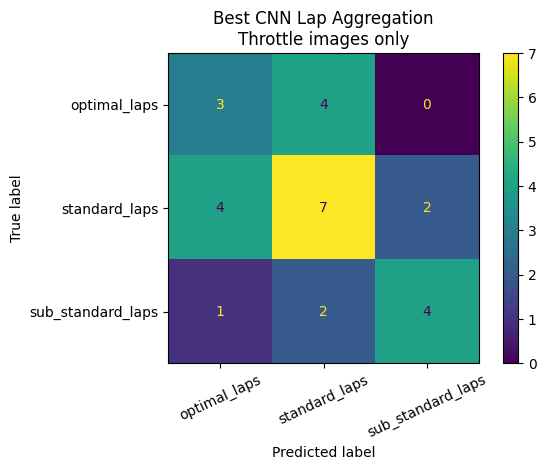

In [39]:
best_aggregation_method = (
    cnn_aggregation_comparison
    .iloc[0]["aggregation_method"]
)

best_prediction_column = (
    aggregation_methods[
        best_aggregation_method
    ]
)

best_aggregation_predictions = (
    cnn_aggregation_results[
        best_prediction_column
    ].to_numpy()
)

print(
    "Best standalone CNN aggregation:",
    best_aggregation_method,
)

print(
    classification_report(
        y_cnn_validation,
        best_aggregation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_cnn_validation,
    best_aggregation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Best CNN Lap Aggregation\n"
    f"{best_aggregation_method}"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [40]:
cnn_aggregation_results_path = (
    manifest_dir
    / "cnn-validation-aggregation-results.csv"
)

cnn_aggregation_comparison_path = (
    manifest_dir
    / "cnn-validation-aggregation-comparison.csv"
)

cnn_aggregation_results.to_csv(
    cnn_aggregation_results_path,
    index=False,
)

cnn_aggregation_comparison.to_csv(
    cnn_aggregation_comparison_path,
    index=False,
)

print(
    "Saved CNN aggregation results:",
    cnn_aggregation_results_path,
)


Saved CNN aggregation results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\cnn-validation-aggregation-results.csv


## 8. CNN and delta probability fusion


In [83]:
fusion_validation_df = (
    throttle_validation_probability_df
    .merge(
        delta_validation_probability_df,
        on="global_lap_num",
        how="inner",
        validate="one_to_one",
    )
)

assert len(fusion_validation_df) == len(
    delta_validation_df
)

assert (
    fusion_validation_df[
        "class_index"
    ]
    == fusion_validation_df[
        "true_class_index"
    ]
).all()

cnn_validation_probabilities = (
    fusion_validation_df[[
        "throttle_probability_optimal",
        "throttle_probability_standard",
        "throttle_probability_sub_standard",
    ]]
    .to_numpy()
)

delta_validation_probabilities = (
    fusion_validation_df[[
        "delta_probability_optimal",
        "delta_probability_standard",
        "delta_probability_sub_standard",
    ]]
    .to_numpy()
)

fusion_true_labels = (
    fusion_validation_df[
        "class_index"
    ].to_numpy()
)

print(
    "Validation laps available for fusion:",
    len(fusion_validation_df),
)

Validation laps available for fusion: 27


In [84]:
fusion_weight_records = []

for cnn_weight in np.linspace(
    0.0,
    1.0,
    101,
):
    delta_weight = 1.0 - cnn_weight

    combined_probabilities = (
        cnn_weight
        * cnn_validation_probabilities
        + delta_weight
        * delta_validation_probabilities
    )

    combined_predictions = (
        combined_probabilities.argmax(
            axis=1
        )
    )

    fusion_weight_records.append({
        "cnn_weight": cnn_weight,
        "delta_weight": delta_weight,
        "accuracy": accuracy_score(
            fusion_true_labels,
            combined_predictions,
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                fusion_true_labels,
                combined_predictions,
            ),
    })

fusion_weight_results = pd.DataFrame(
    fusion_weight_records
)

best_fusion_row = (
    fusion_weight_results
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
            "cnn_weight",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

best_cnn_weight = float(
    best_fusion_row["cnn_weight"]
)

best_delta_weight = float(
    best_fusion_row["delta_weight"]
)

best_fusion_probabilities = (
    best_cnn_weight
    * cnn_validation_probabilities
    + best_delta_weight
    * delta_validation_probabilities
)

best_fusion_predictions = (
    best_fusion_probabilities.argmax(
        axis=1
    )
)

print("Best CNN weight:", best_cnn_weight)
print("Best delta weight:", best_delta_weight)

print(
    "Fusion validation accuracy:",
    f"{accuracy_score(fusion_true_labels, best_fusion_predictions):.4f}",
)

print(
    "Fusion validation balanced accuracy:",
    f"{balanced_accuracy_score(fusion_true_labels, best_fusion_predictions):.4f}",
)

Best CNN weight: 0.21
Best delta weight: 0.79
Fusion validation accuracy: 0.6667
Fusion validation balanced accuracy: 0.6813


                   precision    recall  f1-score   support

     optimal_laps     0.4167    0.7143    0.5263         7
    standard_laps     0.8000    0.6154    0.6957        13
sub_standard_laps     1.0000    0.7143    0.8333         7

         accuracy                         0.6667        27
        macro avg     0.7389    0.6813    0.6851        27
     weighted avg     0.7525    0.6667    0.6874        27



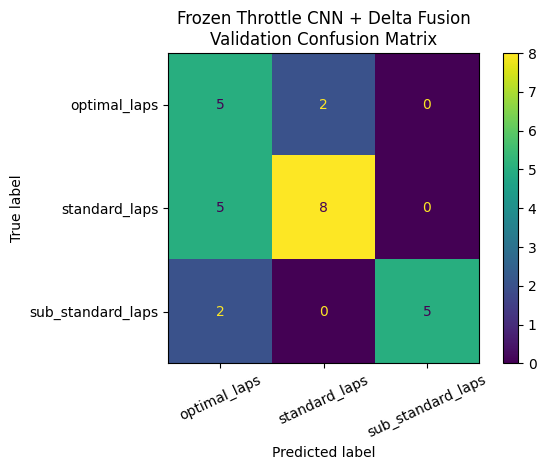

In [85]:
print(
    classification_report(
        fusion_true_labels,
        best_fusion_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    fusion_true_labels,
    best_fusion_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Frozen Throttle CNN + Delta Fusion\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [86]:
partial_fusion_comparison = pd.DataFrame({
    "model": [
        "Majority baseline",
        "Partial throttle-only CNN",
        "Delta logistic regression",
        "Partial throttle CNN + delta fusion",
    ],
    "accuracy": [
        majority_validation_accuracy,
        partial_throttle_accuracy,
        delta_validation_accuracy,
        accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),
    ],
    "balanced_accuracy": [
        majority_validation_balanced_accuracy,
        partial_throttle_balanced_accuracy,
        delta_validation_balanced_accuracy,
        balanced_accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),
    ],
})

display(
    partial_fusion_comparison
)

,model,accuracy,balanced_accuracy
0,Majority baseline,0.481481,0.333333
1,Partial throttle-only CNN,0.555556,0.538462
2,Delta logistic regression,0.592593,0.630037
3,Partial throttle CNN + delta fusion,0.666667,0.681319


In [71]:
fusion_validation_results = (
    fusion_validation_df[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
    ]]
    .copy()
)

fusion_validation_results[
    "fusion_predicted_class_index"
] = best_fusion_predictions

fusion_validation_results[
    "fusion_probability_optimal"
] = best_fusion_probabilities[:, 0]

fusion_validation_results[
    "fusion_probability_standard"
] = best_fusion_probabilities[:, 1]

fusion_validation_results[
    "fusion_probability_sub_standard"
] = best_fusion_probabilities[:, 2]

fusion_validation_results[
    "cnn_weight"
] = best_cnn_weight

fusion_validation_results[
    "delta_weight"
] = best_delta_weight

fusion_results_path = (
    manifest_dir
    / "fusion-validation-results.csv"
)

fusion_validation_results.to_csv(
    fusion_results_path,
    index=False,
)

print(
    "Saved fusion validation results:",
    fusion_results_path,
)


Saved fusion validation results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\fusion-validation-results.csv


## 9. Current data notes

- The fixed split is session-based.
- Train: 85 laps / 340 images.
- Validation: 18 laps / 72 images.
- Test: 19 laps / 76 images.
- Delta data are available for 94 of the 122 eligible laps.
- The test set is intentionally not evaluated during development.
- Set `TRAIN_CNN = True` only when deliberately retraining the CNN.


# Refined model direction

The final classifier could receive:

- 3 mean brake CNN probabilities
- 3 mean throttle CNN probabilities
- delta_1
- delta_2
- delta_gap
- delta_count
- delta_missing

Conceptually:
```
Brake images ── CNN ── brake probabilities ─┐
                                            │
Throttle images ─ CNN ─ throttle probs ─────┼─ Logistic regression ─ final class
                                            │
Brake/throttle deltas ─ telemetry features ─┘
```
Order of changes:

- Evaluate a delta-only logistic regression.
- Aggregate CNN predictions to lap level.
- Tune weighted probability fusion.
- Then train a logistic stacking model using out-of-fold CNN probabilities.

Only after those experiments should we consider changing ResNet18 or building a custom architecture.

The most promising first version is therefore not a larger neural network. It is a session-split lap-level ensemble consisting of ResNet18 plus logistic regression on delta_1 and delta_2.

## Doubts

- I think we have to ensure that the laps without the delta data must be used in training the CNN. 

## A Some clarifications to remember:

### A.1 Image Use Guide
608 total references
- 103 incident images
- 13 images from irregular 2+2 input laps
- 4 images from the lap exceeding 30 seconds

= 488 CNN images

### A.2 Session vs Lap Split 
Keep the current session split as your main evaluation because it is the more defensible generalisation test.

Later, we can also run a secondary lap-grouped experiment using the same model. Comparing them would be informative:

Lap-grouped performance
versus
Session-grouped performance

A large performance drop under session grouping would indicate that session-specific conditions matter substantially. That itself would be a valuable result rather than evidence that the session split was wrong.

vs 

So in order to maintain similar conditions, i made changes to the game settings so that the weather was always the same, same camera position, same setup, no ui, same track conditions, no damage and that includes tye deg., and had these setting in every session. Also the graphics settings were the same too.

The only difference across sessions was my skill which i think you can see from this plot from my analysis notebook.

**Should try lap split later and LOOCV with it too.**

### A.3 Sessions are not of the same size
This might harm the training of the model and its performance

## TODO (might be outdated)
- Create a bespoke CNN model for this data set
- Think about cropping the image to only include the road maybe but I guess the image has to be square
- Think of how much padding should be applied to this CNN based on how important the borders of the image are, consult this article (https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175) and think about the stride too.
- Will probably need to add padding 
- Choose a method to normalize the data you have which is helpful for YOUR data


# Issue
SESSION 20 onwards, the sponsors on the wall are from qatar airways not louis vuitton, so there is a stark difference in colour but that is the extent of the difference.